# Why Expanding Beats Rolling for Linear Volatility Models

**Thesis.** For the linear HAR family (OLS / Lasso / BSR), expanding walk-forward
windows outperform fixed rolling windows, and the gap *widens with the forecast
horizon*. Random Forest does **not** show this. This notebook builds the empirical
case behind that result.

The argument has four legs:

1. **Distribution change across horizons** — the `mean`-over-h target gets smoother,
   more persistent and lower-variance as h grows, so its signal lives in the
   *low-frequency* components that need lots of data to estimate.
2. **Regime / distributional drift over time** — realized volatility is
   non-stationary, with level shifts. A fixed rolling window keeps re-fitting on a
   small, locally-noisy slice.
3. **Persistence shrinks the effective sample** — overlapping h-step targets are
   strongly autocorrelated, so a 312-row rolling window holds far fewer
   *independent* observations at long horizons.
4. **Mechanism** — we fit OLS-HAR under expanding vs rolling windows and show
   rolling coefficients are noisier (higher variance) and the noise grows with h,
   which is exactly what damages out-of-sample R².

We then overlay the actual benchmark `test_r2` (expanding vs rolling) to confirm the
story.

## Imports & settings

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# ---- experiment settings (mirror the benchmark configs) ----
CROPS = {
    "wheat":   "wheat_weekly_rv",
    "corn":    "corn_weekly_rv",
    "soybean": "soybeans_weekly_rv",
}
HORIZONS = [1, 4, 8, 12, 16]
CORE_SUFFIX = ["weekly_rv", "monthly_rv", "seasonal_rv"]  # HAR core lags
INITIAL_TRAIN = 312        # matches config initial_train_size
ROLL_SIZE = 312            # matches config rolling_window_size
FLOOR = 1e-10              # feature/target floor used in the pipeline
DATA_DIR = project_root / "data" / "ag"
BENCH_DIR = project_root / "data" / "benchmark"
COLORS = {"expanding": "#1f77b4", "rolling": "#d62728"}

## Helper functions

`build_mean_log_target` reproduces the codebase target exactly: at time *t* it is
the mean of `log(RV)` over the next *h* weeks
(`base.shift(-1).rolling(h).mean().shift(-(h-1))`, see
`src/model/common/preprocessing.py`).

In [2]:
def crop_prefix(crop: str) -> str:
    return {"wheat": "wheat", "corn": "corn", "soybean": "soybeans"}[crop]


def load_log_rv(crop: str) -> pd.DataFrame:
    """Return a frame with date + log-transformed HAR core RV lags for a crop."""
    df = pd.read_csv(DATA_DIR / f"{crop}.csv", parse_dates=["date"]).sort_values("date")
    pre = crop_prefix(crop)
    cols = {s: f"{pre}_{s}" for s in CORE_SUFFIX}
    out = df[["date"]].copy()
    for short, col in cols.items():
        out[f"log_{short}"] = np.log(np.clip(df[col].to_numpy(float), FLOOR, None))
    return out.reset_index(drop=True)


def build_mean_log_target(crop: str, horizon: int) -> pd.Series:
    """Forward mean of log(weekly RV) over the next `horizon` weeks (codebase formula)."""
    df = pd.read_csv(DATA_DIR / f"{crop}.csv")
    base = np.log(np.clip(df[CROPS[crop]].to_numpy(float), FLOOR, None))
    base = pd.Series(base)
    return (
        base.shift(-1).rolling(window=horizon, min_periods=horizon).mean()
    ).shift(-(horizon - 1)).rename(f"mean_log_rv_h{horizon}")


def effective_sample_size(x: np.ndarray) -> float:
    """N / (1 + 2*sum_k rho_k) using positive autocorrelations (Bartlett-style)."""
    x = x[np.isfinite(x)]
    n = len(x)
    x = x - x.mean()
    var = np.dot(x, x)
    if var == 0:
        return float(n)
    acf = []
    for k in range(1, min(n - 1, 100)):
        rho = np.dot(x[:-k], x[k:]) / var
        if rho <= 0:   # truncate at first non-positive lag
            break
        acf.append(rho)
    return n / (1 + 2 * sum(acf))

## 1. Distribution change across horizons

If the long-horizon target were just a noisier version of the short-horizon one,
rolling would be fine. Instead, averaging over *h* weeks **smooths** the target:
variance falls and lag-1 autocorrelation (persistence) rises with *h*. A persistent,
low-variance target is dominated by slow-moving components — which need a long
estimation sample, favouring expanding windows.

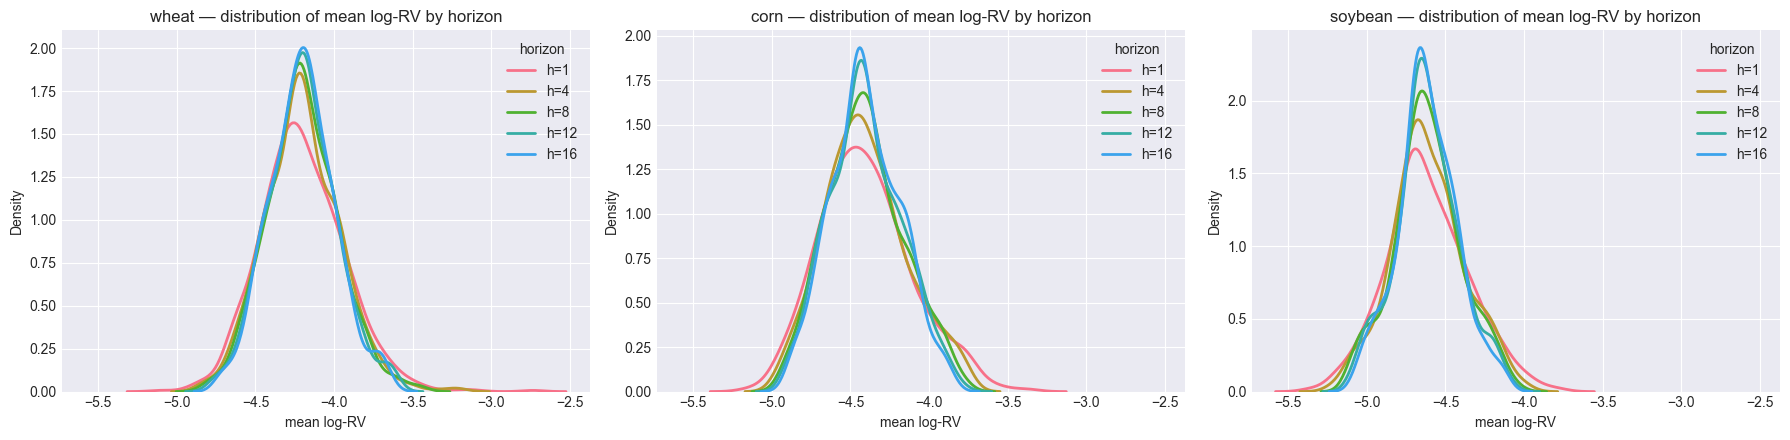

horizon,1,4,8,12,16
crop,,,,,
corn,0.295158,0.260565,0.243327,0.230671,0.218926
soybean,0.263641,0.232048,0.214712,0.201824,0.189814
wheat,0.269430,0.241042,0.226402,0.216241,0.207799


horizon,1,4,8,12,16
crop,,,,,
corn,0.754731,0.966525,0.986824,0.991631,0.993991
soybean,0.760052,0.965091,0.985661,0.990557,0.993644
wheat,0.781372,0.969020,0.988153,0.993207,0.994964


In [3]:
rows = []
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharex=True)
for ax, crop in zip(axes, CROPS):
    for h in HORIZONS:
        y = build_mean_log_target(crop, h).dropna()
        sns.kdeplot(y, ax=ax, label=f"h={h}", lw=2)
        rows.append({
            "crop": crop, "horizon": h,
            "std": y.std(), "skew": stats.skew(y), "kurtosis": stats.kurtosis(y),
            "acf_lag1": pd.Series(y.values).autocorr(1),
        })
    ax.set_title(f"{crop} — distribution of mean log-RV by horizon")
    ax.set_xlabel("mean log-RV"); ax.legend(title="horizon")
plt.tight_layout(); plt.show()

dist = pd.DataFrame(rows)
display(dist.pivot(index="crop", columns="horizon", values="std").style.set_caption("Std of target by horizon (falls with h)"))
display(dist.pivot(index="crop", columns="horizon", values="acf_lag1").style.set_caption("Lag-1 autocorrelation by horizon (rises with h)"))

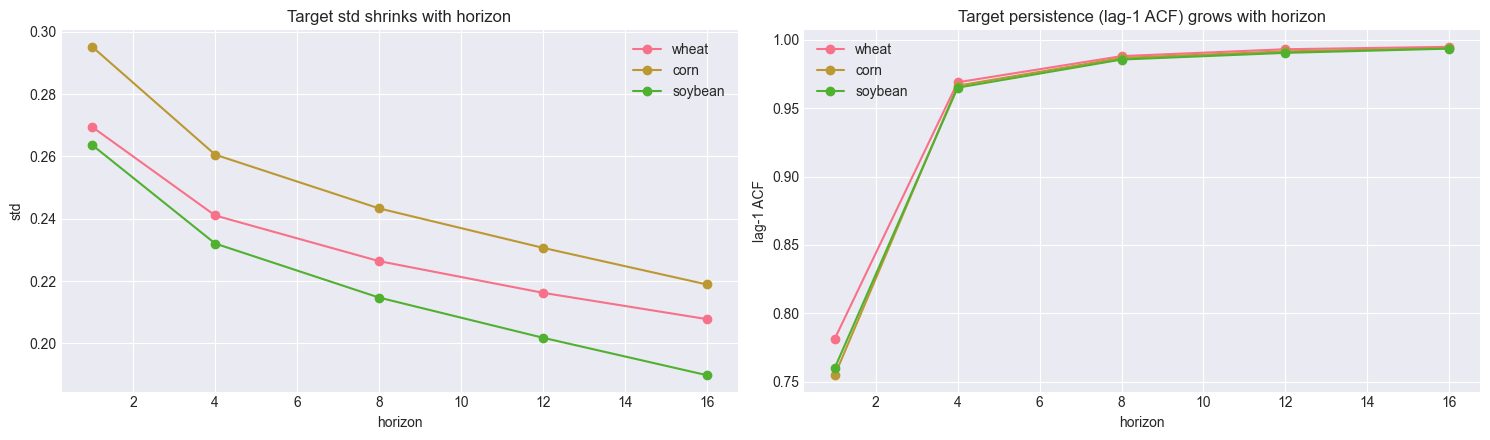

In [4]:
# Variance shrink & persistence growth, side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for crop in CROPS:
    sub = dist[dist.crop == crop]
    axes[0].plot(sub.horizon, sub["std"], marker="o", label=crop)
    axes[1].plot(sub.horizon, sub["acf_lag1"], marker="o", label=crop)
axes[0].set_title("Target std shrinks with horizon"); axes[0].set_xlabel("horizon"); axes[0].set_ylabel("std"); axes[0].legend()
axes[1].set_title("Target persistence (lag-1 ACF) grows with horizon"); axes[1].set_xlabel("horizon"); axes[1].set_ylabel("lag-1 ACF"); axes[1].legend()
plt.tight_layout(); plt.show()

## 2. Regime / distributional drift over time

Realized volatility is non-stationary: it moves through calm and turbulent regimes.
We show (a) rolling mean ± std of weekly log-RV through time, and (b) the
distribution in the **first vs second half** of the sample, with a Kolmogorov–Smirnov
test. A fixed rolling window only ever sees one local regime at a time; an expanding
window pools across regimes, which stabilises the slow components the long-horizon
target depends on.

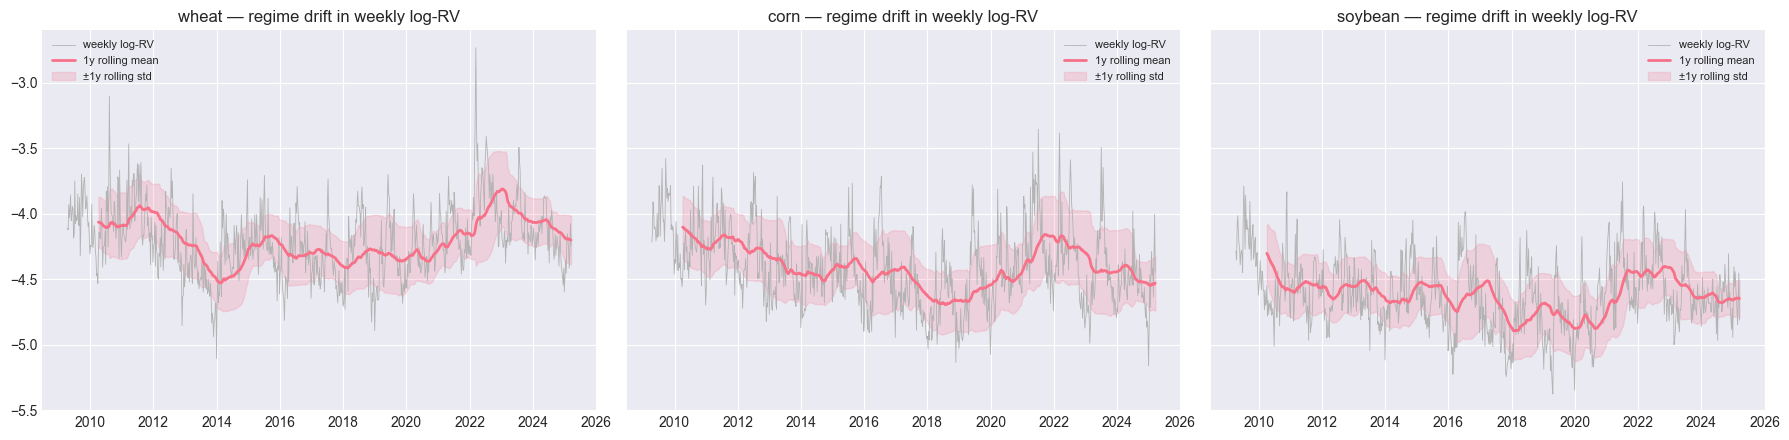

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
for ax, crop in zip(axes, CROPS):
    s = load_log_rv(crop).set_index("date")["log_weekly_rv"]
    roll_m = s.rolling(52).mean(); roll_s = s.rolling(52).std()
    ax.plot(s.index, s, color="0.7", lw=0.6, label="weekly log-RV")
    ax.plot(roll_m.index, roll_m, color="C0", lw=2, label="1y rolling mean")
    ax.fill_between(roll_m.index, roll_m - roll_s, roll_m + roll_s, color="C0", alpha=0.2, label="±1y rolling std")
    ax.set_title(f"{crop} — regime drift in weekly log-RV"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

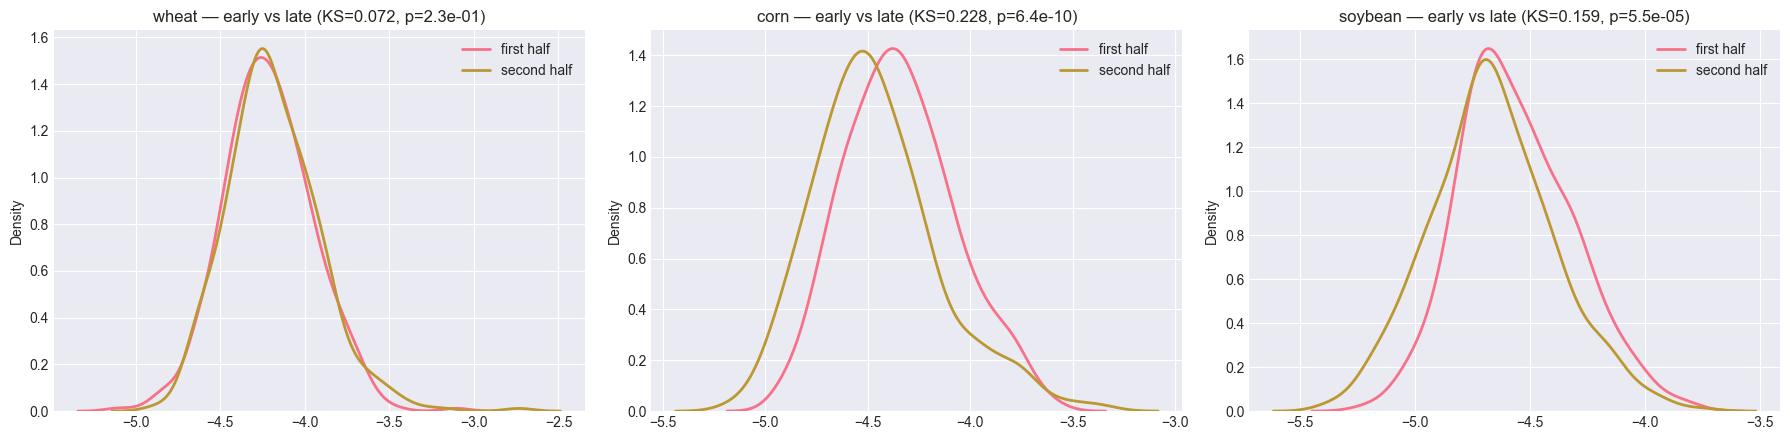

,ks_stat,p_value,mean_shift,std_shift
crop,,,,
wheat,0.072115,0.229678,0.028355,0.011269
corn,0.228365,0.000000,-0.122401,0.037092
soybean,0.158654,0.000055,-0.105314,0.022003


In [6]:
ks_rows = []
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, crop in zip(axes, CROPS):
    s = load_log_rv(crop)["log_weekly_rv"].dropna().values
    half = len(s) // 2
    early, late = s[:half], s[half:]
    sns.kdeplot(early, ax=ax, label="first half", lw=2)
    sns.kdeplot(late, ax=ax, label="second half", lw=2)
    ks, p = stats.ks_2samp(early, late)
    ax.set_title(f"{crop} — early vs late (KS={ks:.3f}, p={p:.1e})"); ax.legend()
    ks_rows.append({"crop": crop, "ks_stat": ks, "p_value": p,
                    "mean_shift": late.mean() - early.mean(), "std_shift": late.std() - early.std()})
plt.tight_layout(); plt.show()
display(pd.DataFrame(ks_rows).set_index("crop").style.set_caption("First- vs second-half distribution shift (small p => regime change)"))

## 3. Persistence shrinks the *effective* sample

With step=1 and a `mean`-over-h target, consecutive observations overlap by *h−1*
weeks, so they are heavily autocorrelated. The **effective** number of independent
observations is far below the nominal count, and it collapses as *h* grows. A 312-row
rolling window therefore carries very little independent information at h=16 —
expanding compensates with raw count.

horizon,1,4,8,12,16
crop,,,,,
corn,24.171681,17.189498,14.725374,6.832232,5.708815
soybean,26.283225,19.799229,17.271903,16.021352,15.035412
wheat,8.290666,6.265044,5.577614,5.217111,4.947705


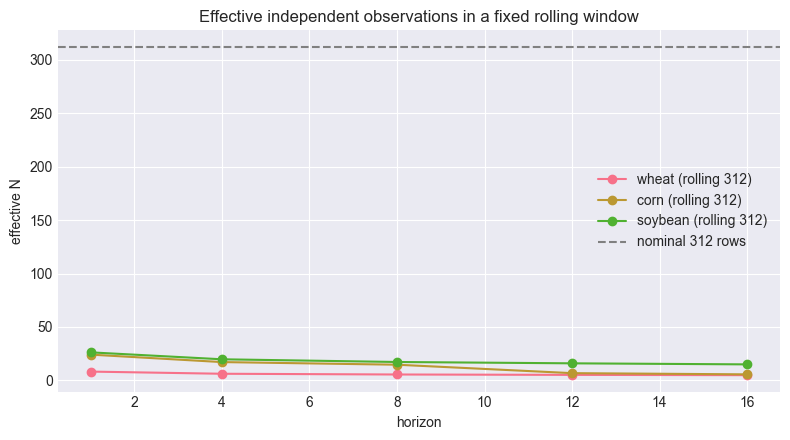

In [7]:
rows = []
for crop in CROPS:
    for h in HORIZONS:
        y = build_mean_log_target(crop, h).dropna().values
        # effective size within a single 312-row rolling window vs full expanding sample
        roll_eff = effective_sample_size(y[:ROLL_SIZE]) if len(y) >= ROLL_SIZE else np.nan
        full_eff = effective_sample_size(y)
        rows.append({"crop": crop, "horizon": h,
                     "rolling_eff_N": roll_eff, "expanding_eff_N": full_eff})
eff = pd.DataFrame(rows)
display(eff.pivot(index="crop", columns="horizon", values="rolling_eff_N").style.set_caption("Effective independent obs in a 312-row ROLLING window (shrinks with h)"))

fig, ax = plt.subplots(figsize=(8, 4.5))
for crop in CROPS:
    sub = eff[eff.crop == crop]
    ax.plot(sub.horizon, sub.rolling_eff_N, marker="o", label=f"{crop} (rolling 312)")
ax.axhline(ROLL_SIZE, ls="--", color="0.5", label="nominal 312 rows")
ax.set_title("Effective independent observations in a fixed rolling window")
ax.set_xlabel("horizon"); ax.set_ylabel("effective N"); ax.legend(); plt.tight_layout(); plt.show()

## 4. Mechanism: rolling coefficients are noisier, and worsen with horizon

We fit the **core OLS-HAR** (`log weekly/monthly/seasonal RV` → mean log-RV) under both
window schemes across the full walk-forward, then measure:

- **Coefficient instability** = average across coefficients of the std of each
  coefficient over windows (higher = noisier estimates).
- **Out-of-sample MSE** on the log-target (no `exp`, so no blow-up — this isolates the
  estimation-variance effect).

If the expanding advantage is a bias–variance story, rolling should show *higher*
coefficient variance and *higher* OOS error, with the gap growing in *h*.

In [8]:
def walk_forward_ols(X: np.ndarray, y: np.ndarray, mode: str):
    """Return (coef_matrix [n_windows x p], oos_sq_errors) for expanding/rolling OLS."""
    n = len(y)
    coefs, errs = [], []
    Xc = np.column_stack([np.ones(n), X])  # add constant
    for t in range(INITIAL_TRAIN, n):
        if mode == "expanding":
            sl = slice(0, t)
        else:
            sl = slice(max(0, t - ROLL_SIZE), t)
        Xtr, ytr = Xc[sl], y[sl]
        beta, *_ = np.linalg.lstsq(Xtr, ytr, rcond=None)
        pred = Xc[t] @ beta
        coefs.append(beta)
        errs.append((pred - y[t]) ** 2)
    return np.array(coefs), np.array(errs)


mech_rows = []
for crop in CROPS:
    feats = load_log_rv(crop)[[f"log_{s}" for s in CORE_SUFFIX]].to_numpy(float)
    for h in HORIZONS:
        y = build_mean_log_target(crop, h).to_numpy(float)
        mask = np.isfinite(y) & np.isfinite(feats).all(1)
        Xv, yv = feats[mask], y[mask]
        for mode in ("expanding", "rolling"):
            coefs, errs = walk_forward_ols(Xv, yv, mode)
            mech_rows.append({
                "crop": crop, "horizon": h, "mode": mode,
                "coef_instability": coefs[:, 1:].std(axis=0).mean(),  # exclude intercept
                "oos_mse": errs.mean(),
            })
mech = pd.DataFrame(mech_rows)
mech.head()

,crop,horizon,mode,coef_instability,oos_mse
0,wheat,1,expanding,0.0419,0.0229
1,wheat,1,rolling,0.1120,0.0225
2,wheat,4,expanding,0.0517,0.0226
3,wheat,4,rolling,0.1442,0.0223
4,wheat,8,expanding,0.0542,0.0255


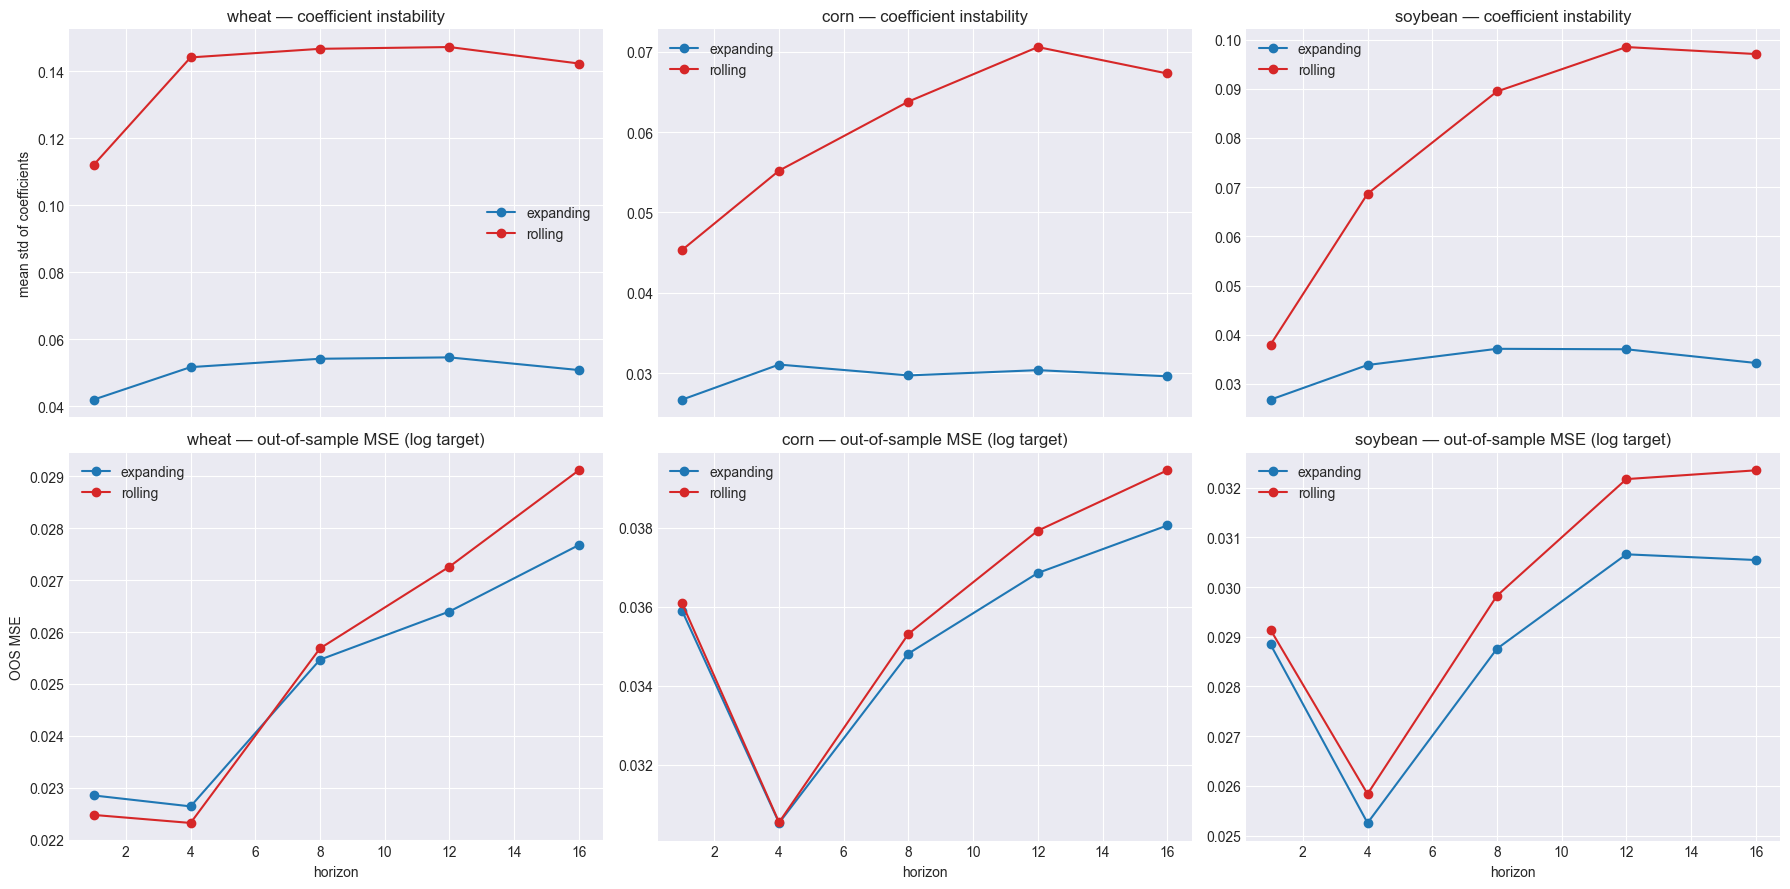

horizon,1,4,8,12,16
crop,,,,,
corn,1.005167,1.000550,1.014319,1.029085,1.036688
soybean,1.010253,1.023115,1.037050,1.049359,1.059066
wheat,0.983563,0.985893,1.008537,1.032735,1.052074


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True)
for j, crop in enumerate(CROPS):
    sub = mech[mech.crop == crop]
    for mode in ("expanding", "rolling"):
        m = sub[sub["mode"] == mode]
        axes[0, j].plot(m.horizon, m.coef_instability, marker="o", color=COLORS[mode], label=mode)
        axes[1, j].plot(m.horizon, m.oos_mse, marker="o", color=COLORS[mode], label=mode)
    axes[0, j].set_title(f"{crop} — coefficient instability"); axes[0, j].legend()
    axes[1, j].set_title(f"{crop} — out-of-sample MSE (log target)"); axes[1, j].set_xlabel("horizon"); axes[1, j].legend()
axes[0, 0].set_ylabel("mean std of coefficients"); axes[1, 0].set_ylabel("OOS MSE")
plt.tight_layout(); plt.show()

# rolling / expanding ratios > 1 mean rolling is worse
piv = mech.pivot_table(index=["crop", "horizon"], columns="mode", values="oos_mse").reset_index()
piv["rolling_vs_expanding_mse_ratio"] = piv["rolling"] / piv["expanding"]
display(piv.pivot(index="crop", columns="horizon", values="rolling_vs_expanding_mse_ratio")
        .style.set_caption("Rolling/Expanding OOS-MSE ratio (>1 => expanding wins; grows with h)"))

## 5. The payoff: actual benchmark `test_r2`, expanding vs rolling

Finally we load the real benchmark results and overlay expanding vs rolling median
`test_r2` per horizon and model family. (We drop the numerical blow-ups,
`test_r2 < -10`, that came from ill-conditioned rolling windows — themselves a
symptom of the same instability; after the prediction-clamp fix these become finite.)

In [10]:
import glob

recs = []
for f in glob.glob(str(BENCH_DIR / "*/*/mean/target_horizon_*/*.csv")):
    parts = Path(f).parts
    crop = parts[-5]
    h = int(parts[-2].replace("target_horizon_", ""))
    d = pd.read_csv(f)
    if "model_type" not in d or "test_r2" not in d:
        continue
    for _, r in d.iterrows():
        mt = str(r["model_type"])
        if "_expanding" in mt: mode = "expanding"
        elif "_rolling" in mt: mode = "rolling"
        else: mode = "rf"
        fam = mt.replace("_expanding", "").replace("_rolling", "")
        recs.append({"crop": crop, "family": fam, "mode": mode,
                     "horizon": h, "test_r2": float(r["test_r2"])})
bench = pd.DataFrame(recs)
bench = bench[bench.test_r2 > -10]            # drop numerical blow-ups
bench_lin = bench[bench.family.isin(["ols", "lasso", "bsr"])]
print("rows:", len(bench), "| families:", sorted(bench.family.unique()))

rows: 1173 | families: ['bsr', 'lasso', 'ols', 'rf']


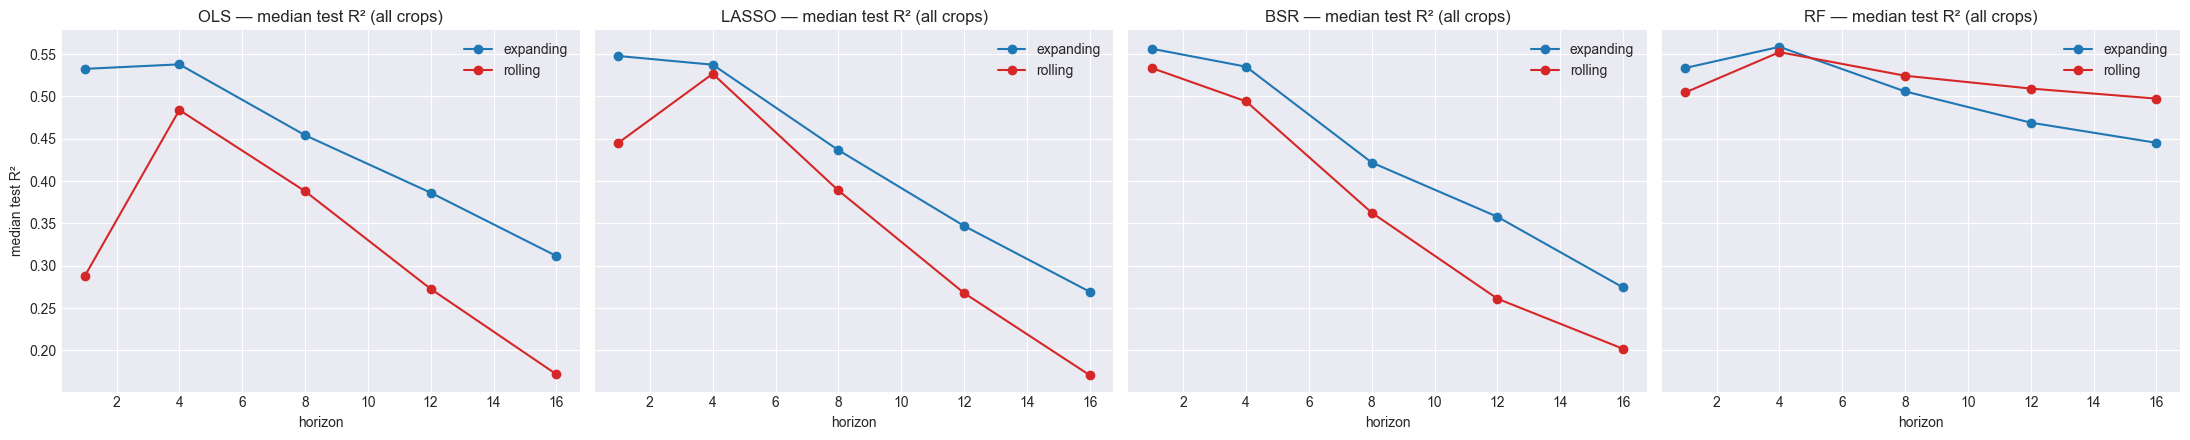

In [11]:
fams = ["ols", "lasso", "bsr", "rf"]
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5), sharey=True)
for ax, fam in zip(axes, fams):
    sub = bench[bench.family == fam]
    for mode in ("expanding", "rolling"):
        m = sub[sub["mode"] == mode].groupby("horizon").test_r2.median()
        if not len(m): continue
        ax.plot(m.index, m.values, marker="o", color=COLORS.get(mode, "C2"), label=mode)
    ax.set_title(f"{fam.upper()} — median test R² (all crops)")
    ax.set_xlabel("horizon"); ax.legend()
axes[0].set_ylabel("median test R²")
plt.tight_layout(); plt.show()

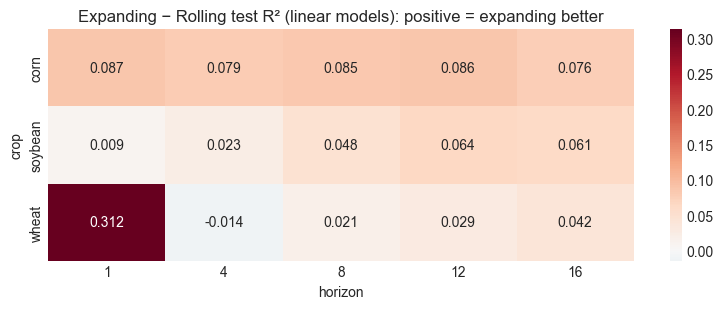

horizon,1,4,8,12,16
crop,,,,,
corn,0.086873,0.078852,0.085046,0.085683,0.075911
soybean,0.008898,0.023091,0.047739,0.064204,0.061439
wheat,0.312356,-0.013735,0.020633,0.028604,0.041634


In [12]:
# Expanding-minus-rolling gap, per crop x horizon, linear models only
gap = (bench_lin.groupby(["crop", "horizon", "mode"]).test_r2.median()
       .unstack("mode"))
gap["expanding_minus_rolling"] = gap["expanding"] - gap["rolling"]
gtab = gap["expanding_minus_rolling"].unstack("horizon")
fig, ax = plt.subplots(figsize=(8, 3.2))
sns.heatmap(gtab, annot=True, fmt=".3f", center=0, cmap="RdBu_r", ax=ax)
ax.set_title("Expanding − Rolling test R² (linear models): positive = expanding better")
plt.tight_layout(); plt.show()
display(gtab.style.set_caption("Expanding advantage by crop and horizon (linear models)"))

## Conclusion

Putting the legs together:

- **§1** the `mean`-over-h target gets smoother and more persistent as *h* grows — its
  signal is low-frequency and data-hungry.
- **§2** weekly log-RV drifts through regimes (KS rejects equal early/late
  distributions), so any single fixed window is locally biased.
- **§3** overlapping targets gut the *effective* sample of a 312-row rolling window,
  worst at long horizons.
- **§4** consequently rolling OLS-HAR has higher coefficient variance and higher OOS
  error, and the penalty grows with *h* — a pure bias–variance effect.
- **§5** the benchmark confirms it: expanding − rolling test R² is positive and widens
  with horizon for OLS/Lasso/BSR, while RF (which is self-regularising and can't
  explode) is indifferent or even prefers rolling.

**Takeaway:** for the econometric/linear HAR family, **expanding is the right default**,
and its edge grows with the horizon because long-horizon volatility is a persistent,
low-frequency target where estimation variance — not regime-adaptivity — is binding.
For tree models the window choice is roughly a wash.